##### Библиотеки и импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (12, 8)

from sklearn.decomposition import PCA, FastICA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, v_measure_score

np.random.seed(0)

##### Загрузка данных

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv'
cols = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
dataset = pd.read_csv(url, names=cols)

print("Форма датасета:", dataset.shape)
dataset.head()

Форма датасета: (150, 5)


,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


содержит 150 строк и 5 столбцов: 4 числовых признака (длина и ширина чашелистника и лепестка) и 1 целевой столбец class

#### EDA

In [3]:
print("Информация о датасете:")
print(dataset.info())
print("\nСтатистическое описание:")
print(dataset.describe())
print("\nРаспределение классов:")
print(dataset['class'].value_counts())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal-length  150 non-null    float64
 1   sepal-width   150 non-null    float64
 2   petal-length  150 non-null    float64
 3   petal-width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Статистическое описание:
       sepal-length  sepal-width  petal-length  petal-width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max      

Пропусков нет, все 150 записей полные по всем 5 столбцам. Классы сбалансированы(ровно по 50 образцов каждого вида), признаки сильно различаются по разбросу  

тут подготовим данные

In [4]:
cols_for_clusters = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width']
df = dataset[cols_for_clusters].copy()

vals = dataset['class'].unique()
X = df
y = dataset['class'].replace(vals, [0, 1, 2])
yvals = dataset['class']

print("Уникальные классы:", vals)
print("Форма X:", X.shape)
print("Форма y:", y.shape)


Уникальные классы: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Форма X: (150, 4)
Форма y: (150,)


C:\Users\RomanovHome\AppData\Local\Temp\ipykernel_9060\1813595626.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = dataset['class'].replace(vals, [0, 1, 2])


X содержит 150 образцов и 4 числовых признака, y вектор меток длиной 150

#### PCA Метод главных компонент

Доля объяснённой дисперсии по компонентам: [0.92461621 0.05301557]
Суммарная объяснённая дисперсия: 0.9776317750248061


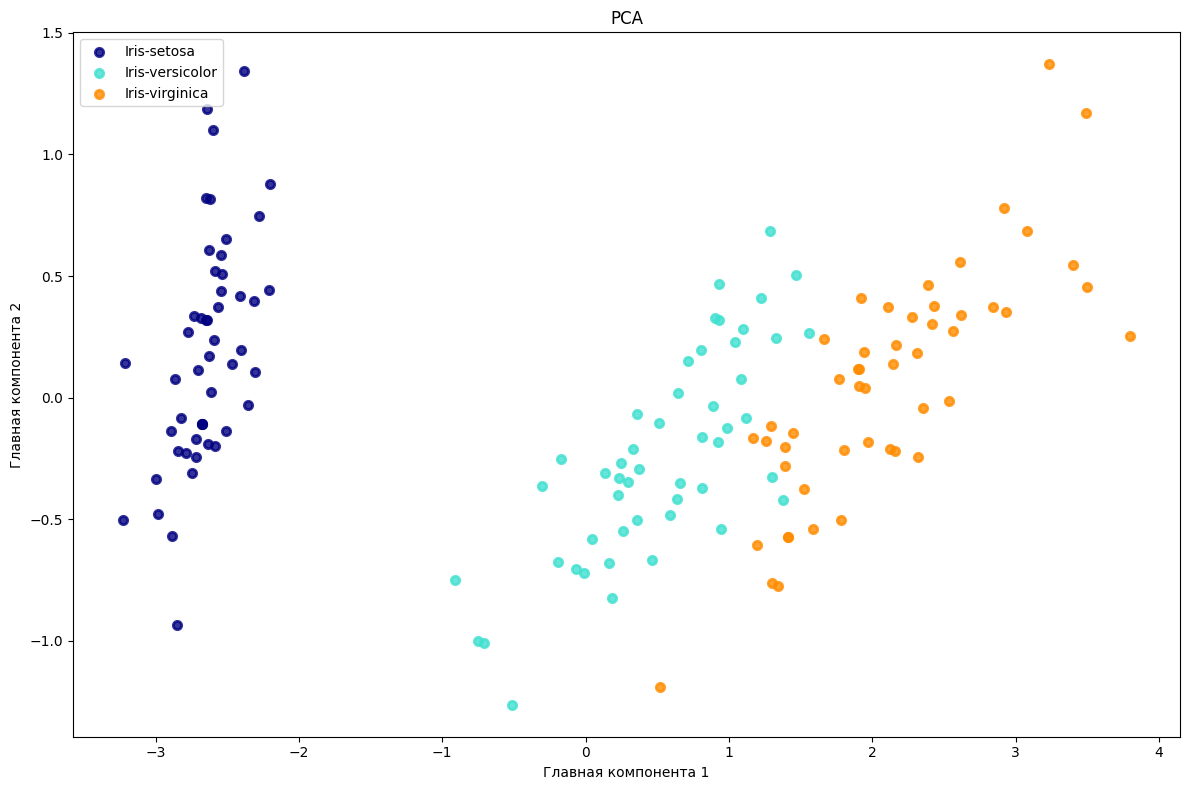

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit(X).transform(X)

print("Доля объяснённой дисперсии по компонентам:", pca.explained_variance_ratio_)
print("Суммарная объяснённая дисперсия:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(12, 8))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], vals):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                color=color, alpha=0.8, lw=lw, label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.tight_layout()
plt.show()


Первая главная компонента объясняет 92.5% дисперсии, вторая компонента добавляет лишь 5.3%. 
Iris-setosa (тёмно-синий) полностью изолирован слева
Iris-versicolor (бирюзовый) и Iris-virginica (оранжевый) частично перекрываются

 Оцениваем, сколько информации (дисперсии) сохраняется при понижении размерности. Чем выше суммарная объяснённая дисперсия, тем меньше информации теряется

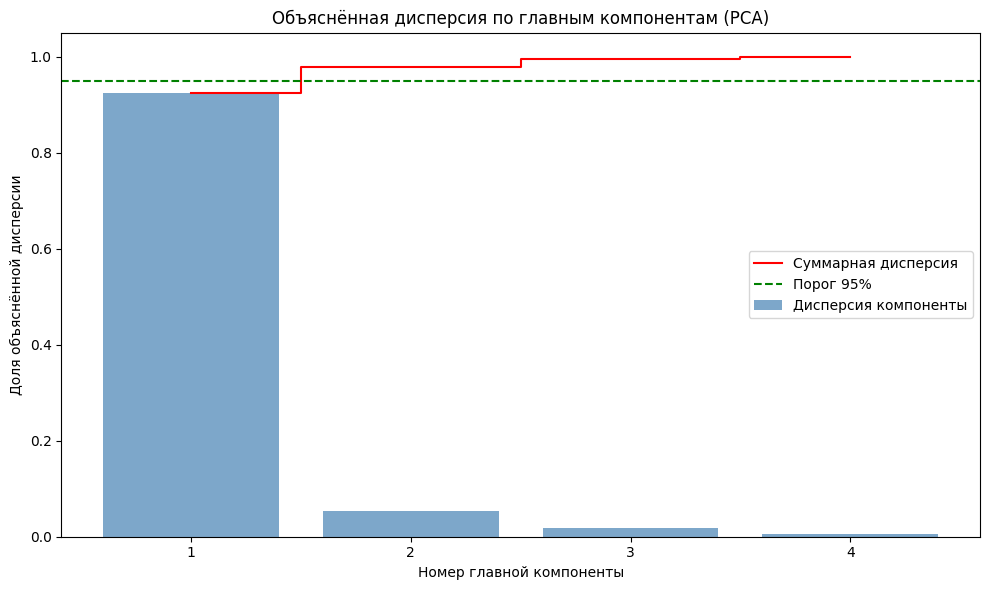

Объяснённая дисперсия по компонентам: [0.92461621 0.05301557 0.01718514 0.00518309]


In [6]:
pca_full = PCA()
pca_full.fit(X)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_,
        alpha=0.7, color='steelblue', label='Дисперсия компоненты')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance,
         where='mid', color='red', label='Суммарная дисперсия')
plt.axhline(y=0.95, color='green', linestyle='--', label='Порог 95%')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Объяснённая дисперсия по главным компонентам (PCA)')
plt.legend(loc='center right')
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.tight_layout()
plt.show()

print("Объяснённая дисперсия по компонентам:", pca_full.explained_variance_ratio_)

достаточно 2 главных компоненты, чтобы сохранить больше 97% информации

#### метод понижения размерности (FastICA)

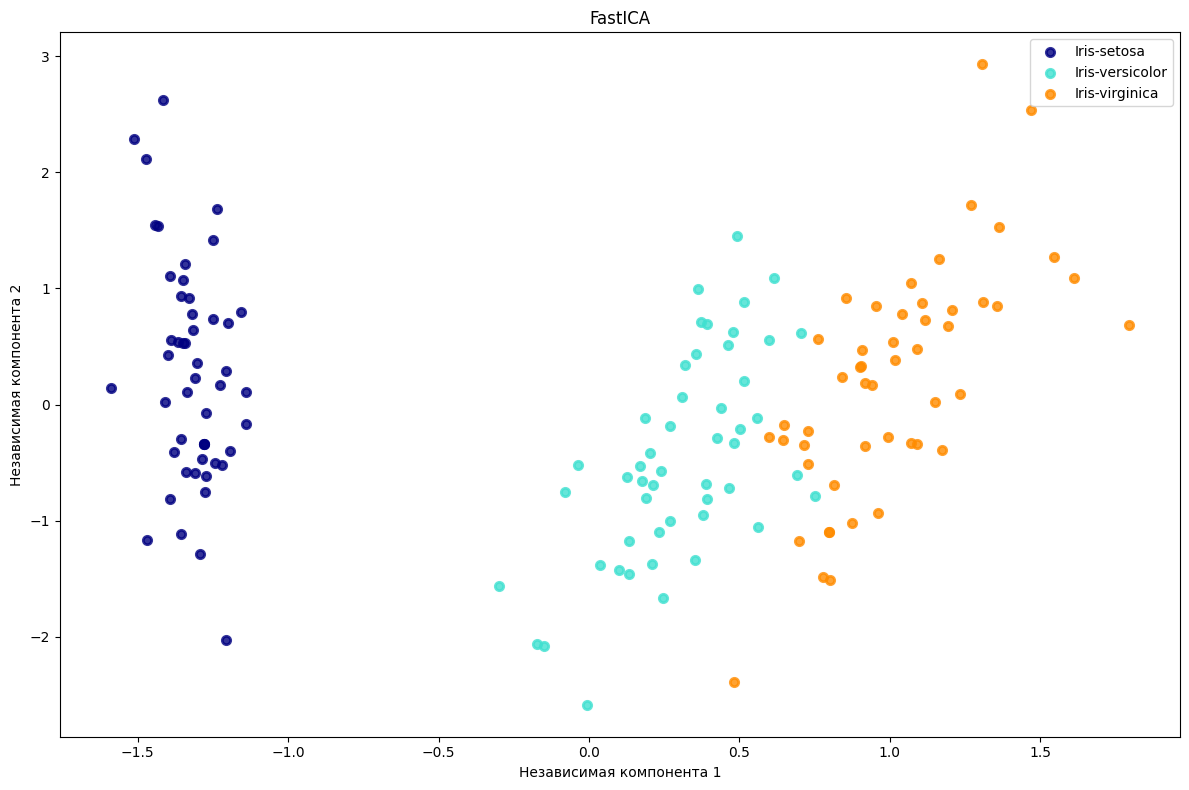

In [7]:
fastica = FastICA(n_components=2)
X_ica = fastica.fit_transform(X)

plt.figure(figsize=(12, 8))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], vals):
    plt.scatter(X_ica[y == i, 0], X_ica[y == i, 1],
                color=color, alpha=0.8, lw=lw, label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('FastICA')
plt.xlabel('Независимая компонента 1')
plt.ylabel('Независимая компонента 2')
plt.tight_layout()
plt.show()


FastICA воспроизводит структуру кластеров, аналогичную PCA, не даёт значительного улучшения по сравнению с PCA, оба метода справляются примерно одинаково

#### Ядерный метод главных компонент (KernelPCA)

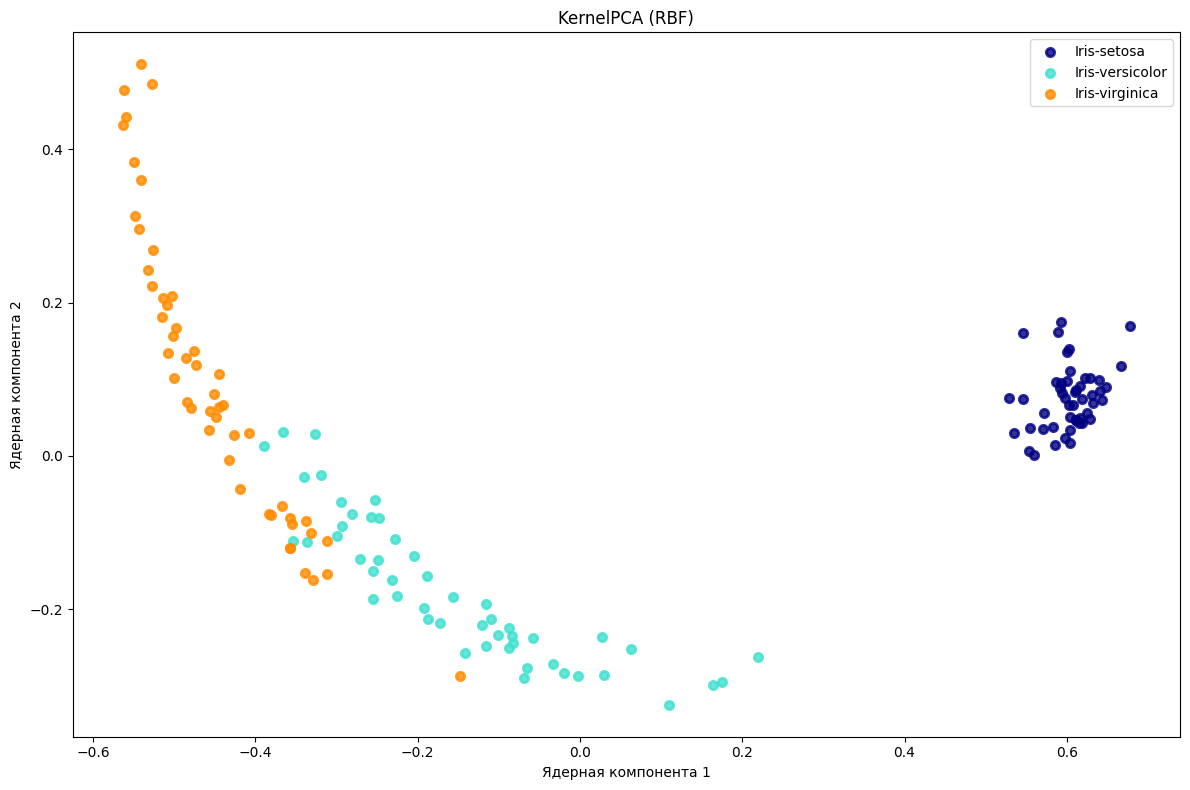

In [8]:
rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_kpca = rbf_pca.fit_transform(X)

plt.figure(figsize=(12, 8))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], vals):
    plt.scatter(X_kpca[y == i, 0], X_kpca[y == i, 1],
                color=color, alpha=0.8, lw=lw, label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('KernelPCA (RBF)')
plt.xlabel('Ядерная компонента 1')
plt.ylabel('Ядерная компонента 2')
plt.tight_layout()
plt.show()


теперь кардинально отличается от PCA и FastICA

KernelPCA лучше изолирует сетозу, но хуже разделяет версиколор и вирджинику по сравнению с линейными методами

#### Стохастическое вложение соседних точек (t-SNE)

Исходная форма X: (150, 4)
Новая форма X после t-SNE: (150, 2)
Расстояние Куллбака-Лейблера после оптимизации: 0.11946870386600494
Число итераций: 999


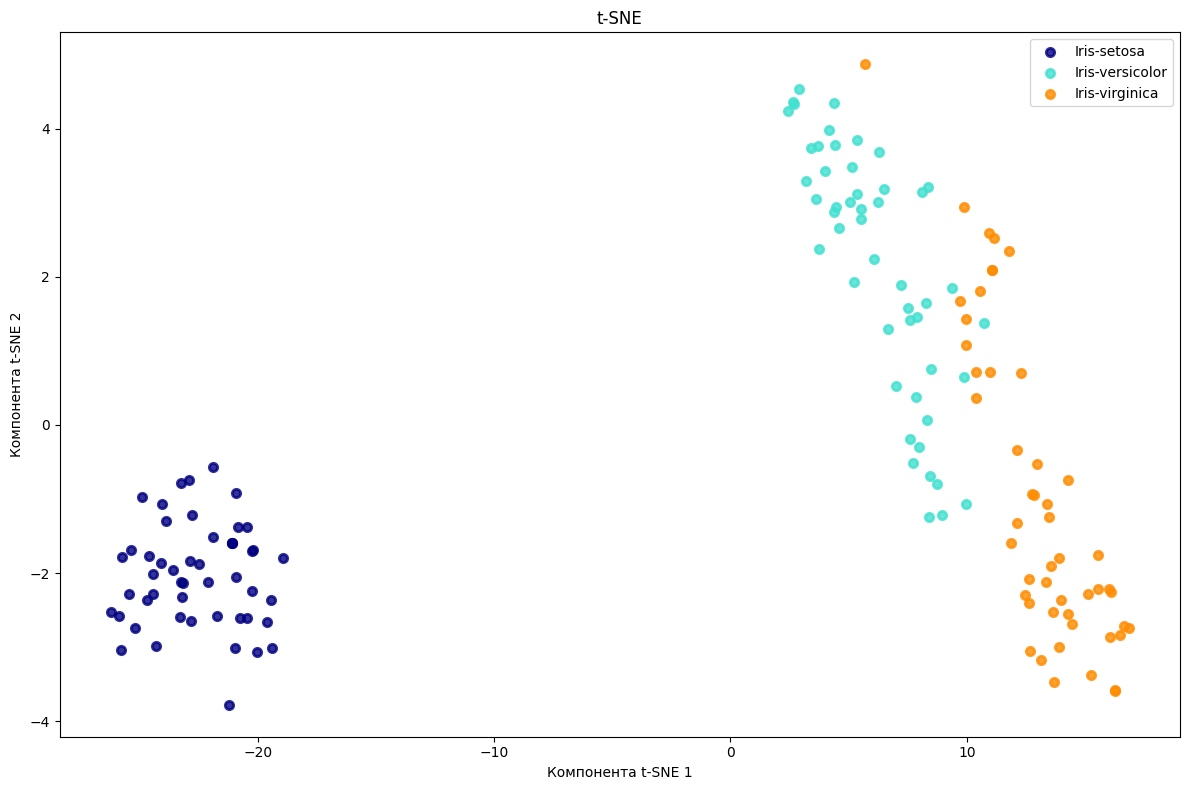

In [9]:
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)

print("Исходная форма X:", X.shape)
print("Новая форма X после t-SNE:", X_tsne.shape)
print("Расстояние Куллбака-Лейблера после оптимизации:", tsne.kl_divergence_)
print("Число итераций:", tsne.n_iter_)

plt.figure(figsize=(12, 8))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], vals):
    plt.scatter(X_tsne[y == i, 0], X_tsne[y == i, 1],
                color=color, alpha=0.8, lw=lw, label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('t-SNE')
plt.xlabel('Компонента t-SNE 1')
plt.ylabel('Компонента t-SNE 2')
plt.tight_layout()
plt.show()


похожий результат с первыми двумя методами, но setosa стала кучнее

####  Выбор параметра eps для DBSCAN (метод k-ближайших соседей)

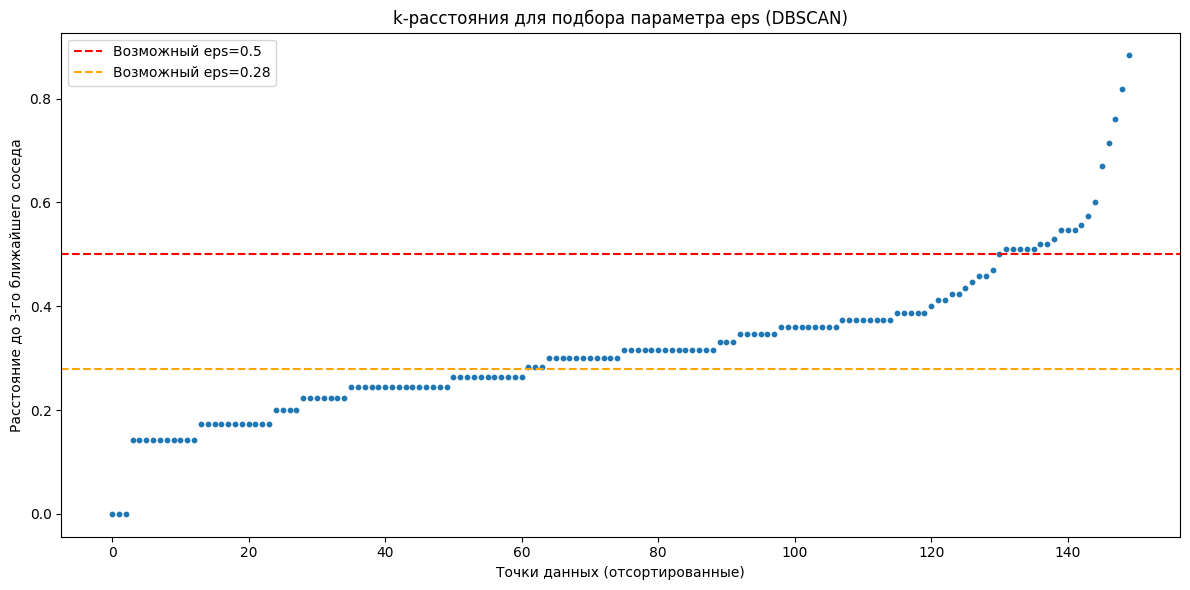

In [12]:
min_samples = 3
knn = NearestNeighbors(n_neighbors=min_samples, metric='l2')
knn.fit(X)
dists, inds = knn.kneighbors(X)

dists_arr = dists[:, -1]
dists_arr.sort()

plt.figure(figsize=(12, 6))
plt.scatter(range(len(dists_arr)), dists_arr, s=10)
plt.title('k-расстояния для подбора параметра eps (DBSCAN)')
plt.xlabel('Точки данных (отсортированные)')
plt.ylabel(f'Расстояние до {min_samples}-го ближайшего соседа')
plt.axhline(y=0.5,  color='red',    linestyle='--', label='Возможный eps=0.5')
plt.axhline(y=0.28, color='orange', linestyle='--', label='Возможный eps=0.28')
plt.legend()
plt.tight_layout()
plt.show()


eps=0.28 более строгий порог
eps=0.5 более мягкий порог: меньше шума, но кластеры будут крупнее и менее плотными



Кластеризация DBSCAN (eps=0.28)

Оценочное число кластеров: 8
Оценочное число шумовых точек: 74
V-мера: 0.4351042960575002


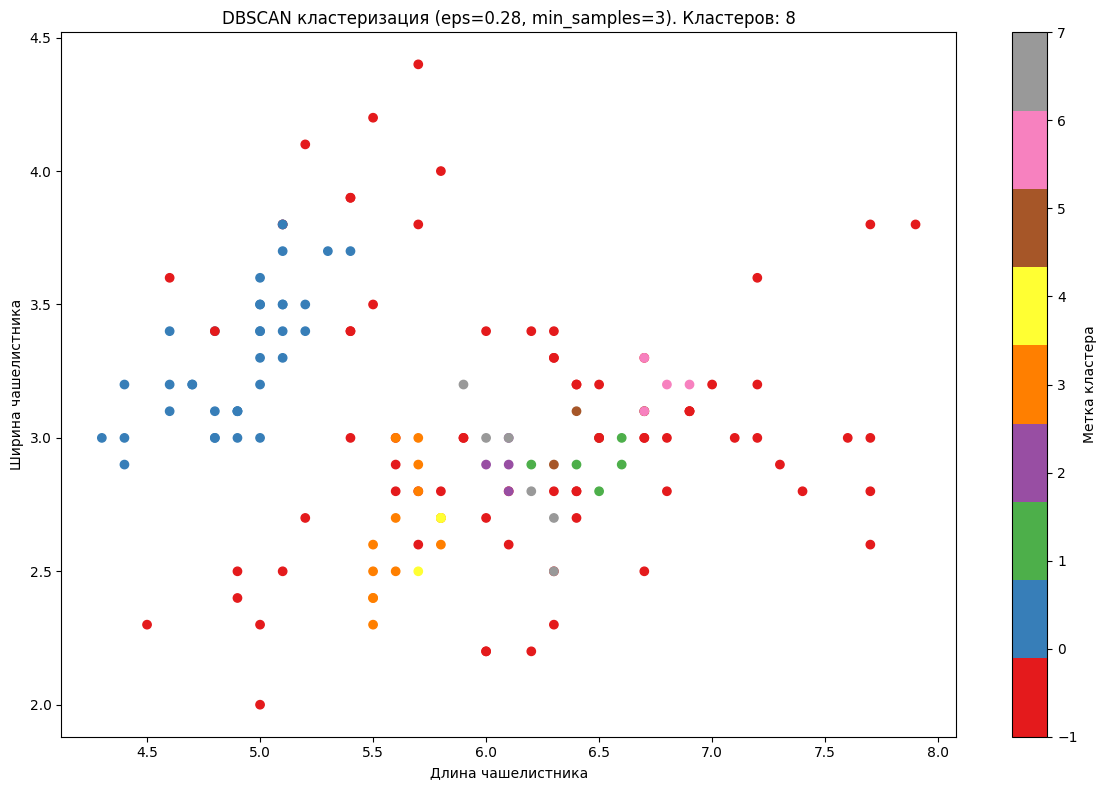

In [13]:
dbscan_cluster1 = DBSCAN(eps=0.28, min_samples=3)
dbscan_cluster1.fit(X)

labels1 = dbscan_cluster1.labels_
n_clus  = len(set(labels1)) - (1 if -1 in labels1 else 0)
n_noise = list(dbscan_cluster1.labels_).count(-1)

print("Оценочное число кластеров:", n_clus)
print("Оценочное число шумовых точек:", n_noise)
print("V-мера:", v_measure_score(y, labels1))

plt.figure(figsize=(12, 8))
plt.scatter(X[cols_for_clusters[0]], X[cols_for_clusters[1]],
            c=dbscan_cluster1.labels_, cmap='Set1')
plt.title(f'DBSCAN кластеризация (eps=0.28, min_samples=3). Кластеров: {n_clus}')
plt.xlabel('Длина чашелистника')
plt.ylabel('Ширина чашелистника')
plt.colorbar(label='Метка кластера')
plt.tight_layout()
plt.show()


eps=0.28 слишком маленькое значение для данного датасета. параметр нужно увеличить

DBSCAN (eps=0.5)

DBSCAN(min_samples=3)
Оценочное число кластеров: 4
Оценочное число шумовых точек: 10
V-мера: 0.6133993238518761
Найдено аномалий: 10
     sepal-length  sepal-width  petal-length  petal-width
41            4.5          2.3           1.3          0.3
68            6.2          2.2           4.5          1.5
87            6.3          2.3           4.4          1.3
106           4.9          2.5           4.5          1.7
108           6.7          2.5           5.8          1.8
109           7.2          3.6           6.1          2.5
117           7.7          3.8           6.7          2.2
131           7.9          3.8           6.4          2.0
134           6.1          2.6           5.6          1.4
135           7.7          3.0           6.1          2.3


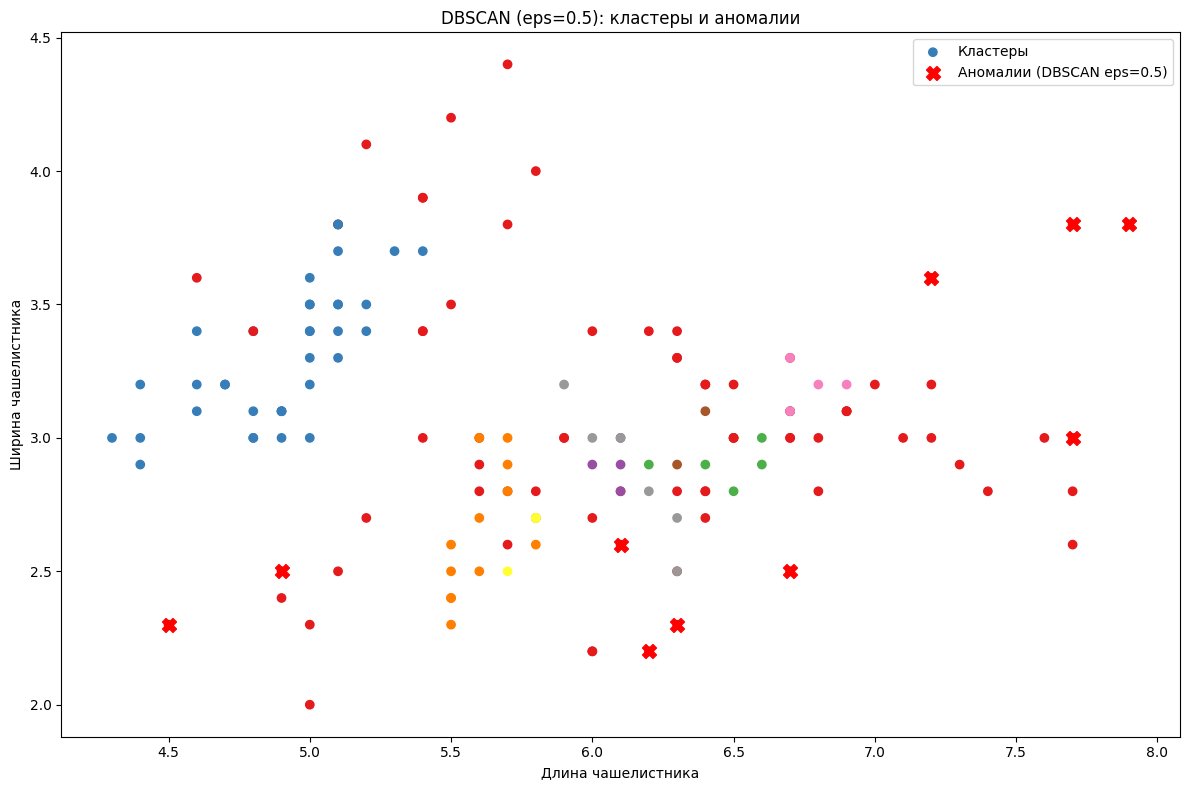

In [14]:
dbscan = DBSCAN(eps=0.5, min_samples=min_samples)
print(dbscan)
pred = dbscan.fit_predict(X)

labels2 = dbscan.labels_
n_clus2  = len(set(labels2)) - (1 if -1 in labels2 else 0)
n_noise2 = list(dbscan.labels_).count(-1)

print("Оценочное число кластеров:", n_clus2)
print("Оценочное число шумовых точек:", n_noise2)
print("V-мера:", v_measure_score(y, labels2))

# Аномалии — точки с меткой -1
anom_index = [i for i in range(len(pred)) if pred[i] == -1]
values = X.loc[anom_index]
print(f"Найдено аномалий: {len(values)}")
print(values)

plt.figure(figsize=(12, 8))
plt.scatter(X[cols_for_clusters[0]], X[cols_for_clusters[1]],
            c=dbscan_cluster1.labels_, cmap='Set1', label='Кластеры')
plt.scatter(values[cols_for_clusters[0]], values[cols_for_clusters[1]],
            color='red', s=100, marker='X', zorder=5,
            label='Аномалии (DBSCAN eps=0.5)')
plt.title('DBSCAN (eps=0.5): кластеры и аномалии')
plt.xlabel('Длина чашелистника')
plt.ylabel('Ширина чашелистника')
plt.legend()
plt.tight_layout()
plt.show()


eps=0.5 значительно лучше подходит для данного датасета